<a href="https://colab.research.google.com/github/DhanshreeRaut/Pattern-Recognition/blob/main/CM23059_PRACTICAL5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# PRACTICAL: Customer Segmentation using K-Means and
# Hierarchical Clustering
# ==========================================================

# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score


In [2]:
# ----------------------------------------------------------
# Step 2: Load Dataset
# ----------------------------------------------------------

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Mall_Customers.csv")

print("First 5 Records")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Saving Mall_Customers.csv to Mall_Customers.csv
First 5 Records


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Shape: (200, 5)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
# ----------------------------------------------------------
# Step 3: Select Features
# ----------------------------------------------------------
# Customer purchasing behaviour is analysed using
# Annual Income and Spending Score.

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [4]:
# ----------------------------------------------------------
# Step 4: Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Finding Optimal Number of Clusters...


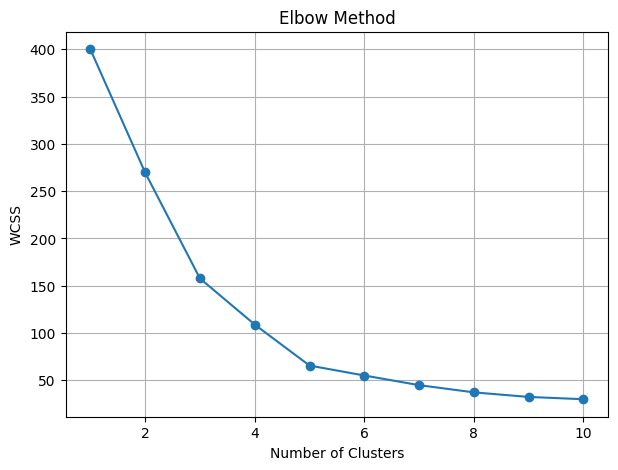

In [5]:
# ==========================================================
#               K-MEANS CLUSTERING
# ==========================================================

print("\nFinding Optimal Number of Clusters...")

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


In [6]:
# ----------------------------------------------------------
# Train KMeans Model
# ----------------------------------------------------------

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


In [7]:
# ----------------------------------------------------------
# Silhouette Score
# ----------------------------------------------------------

score = silhouette_score(X_scaled, df['KMeans_Cluster'])

print("\nSilhouette Score:", round(score,3))



Silhouette Score: 0.555


In [8]:
# ----------------------------------------------------------
# Cluster Centers
# ----------------------------------------------------------

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("\nCluster Centers")

cluster_centers = pd.DataFrame(
    centers,
    columns=['Annual Income','Spending Score']
)

display(cluster_centers)



Cluster Centers


,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


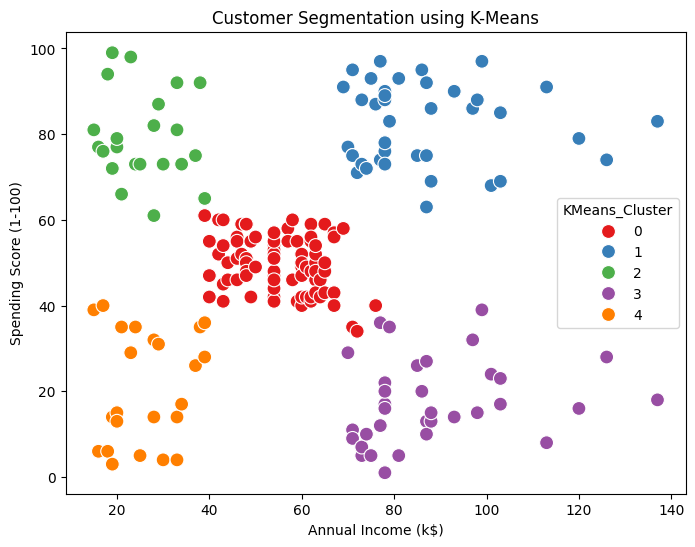

In [9]:
# ----------------------------------------------------------
# Visualize KMeans
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.show()


Generating Dendrogram...


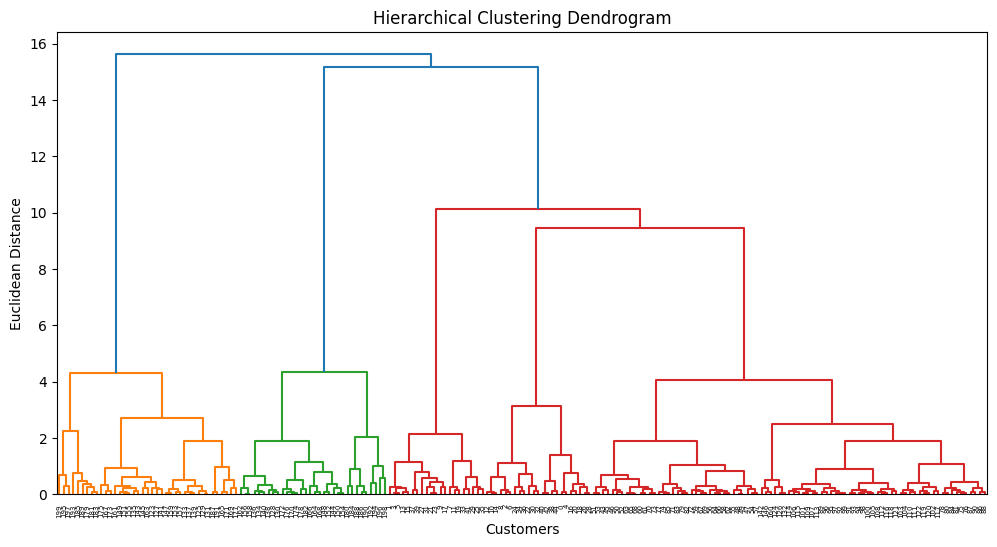

In [10]:
# ==========================================================
#          HIERARCHICAL CLUSTERING
# ==========================================================

print("\nGenerating Dendrogram...")

plt.figure(figsize=(12,6))

linkage_matrix = linkage(X_scaled, method='ward')

dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

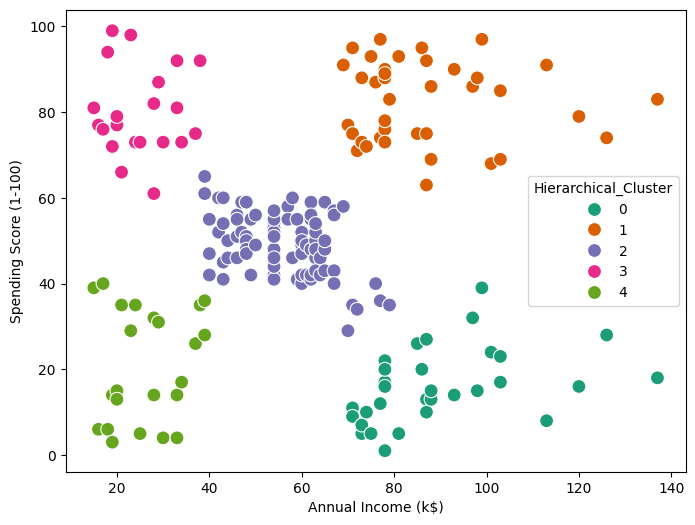

In [12]:
# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Hierarchical_Cluster',
    palette='Dark2',
    s=100
)
